# Decision Trees
## Artificial Intelligence in Games

In [254]:
import sklearn
import pandas as pd
import numpy as np

In [258]:
df_laps = pd.read_csv("training data/training_data2.csv") 

mask = df_laps['action'] == 'none' # remove none entry rows
df_laps = df_laps[~mask]
df_laps

,north,north_west,north_east,south,west,east,action,lap
0,100,59,59,100,36,35,accelerate,1
1,100,59,59,100,36,35,accelerate,1
2,100,59,59,100,36,35,accelerate,1
3,100,59,59,100,36,35,accelerate,1
4,100,59,59,100,36,35,accelerate,1
...,...,...,...,...,...,...,...,...
11028,100,53,67,100,36,36,accelerate,14
11029,100,51,69,100,35,37,accelerate,14
11030,100,51,69,100,35,37,accelerate,14
11031,100,51,69,100,35,37,accelerate,14


Before starting the learning process we need to explicitely separate the dependent from the independent variables and use only the relevant columns of the data set (columns 1,2,3 and 4); we need also th extract the feature names - they will be useful in the future to interpret the resulting models.

In [189]:
col_idxs = [0,1,2,3,4,5]
col_names = np.array(df_laps.columns)[col_idxs]
col_names

array(['north', 'north_west', 'north_east', 'south', 'west', 'east'],
      dtype=object)

Lets display the attribute values ignoring the last column correspondig to the leaning class:

In [192]:
X = df_laps.values[:1,col_idxs]

print(X)

[[100 59 59 100 36 35]]


Now we display only the class values, item :

In [195]:
y = df_laps.values[:,6]
print(y)

['accelerate' 'accelerate' 'accelerate' ... 'accelerate' 'accelerate'
 'accelerate']


We might see the dummy varaibles with their binary values, in fact the boolean values are treated as numeric, as integers. 

In [197]:
# build the dataframe X
df_laps_X = df_laps[col_names]

# convert into a dummy DataFrame
df_laps_Xdum = pd.get_dummies(df_laps_X, dtype = int)

# Extract the new feature names.
int_col_names_dum = np.array(df_laps_Xdum.columns)

df_laps_Xdum
df_laps_Xdum_val = df_laps_Xdum.values
df_laps_Xdum_val

array([[100,  59,  59, 100,  36,  35],
       [100,  59,  59, 100,  36,  35],
       [100,  59,  59, 100,  36,  35],
       ...,
       [100,  51,  69, 100,  35,  37],
       [100,  51,  69, 100,  35,  37],
       [100,  50,  71, 100,  34,  38]])

### 1.2. Training a Decision Tree classifier using scikit-learn

In [202]:
from sklearn.tree import DecisionTreeClassifier

sk_dt = DecisionTreeClassifier(criterion = "entropy")
sk_dt.fit(df_laps_Xdum_val, y)

DecisionTreeClassifier(criterion='entropy')

In [262]:
import joblib

joblib.dump(sk_dt, "trained_tree_model.pkl")

['trained_tree_model.pkl']

## 2. Decision Tree Display
### 2.1 Decision tree in txt mode

In [ ]:
from sklearn.tree import export_text
the_tree = export_text(sk_dt,feature_names = list(int_col_names_dum))
print(the_tree)

### 2.2.Display the trees graphically

Podemos contudo melhorar o output, exportanto o resultado para o formato de imagem que pode ser visualizado no notebook. O scikit-learn tem uma forma de o fazer através da função <a href="https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html">`plot_tree`</a>
```python
plot_tree(decision_tree, *, max_depth=None, feature_names=None, class_names=None, label='all', filled=False, impurity=True, node_ids=False, proportion=False, rotate='deprecated', rounded=False, precision=3, ax=None, fontsize=None)
```
the following arguments are the most relevant to visualize the decision tree:
* `decision_tree` - The trained tree
* `feature_names` - list with the names of the attributes, otherwise X[0], X[1], ...
* `class_names` - list with the name of the classes, otherwise no classification will appear in the leaves.
* `filled` - `False` by default. in case the value is `True`, the tree nodes are filled with a color that indicates the classes: it will be the one that is most frequent in the data that fits de respective decision tree branch, since the root.

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=[3,2]) # width, height in inches
plot_tree(sk_dt, 
          feature_names = list(int_col_names_dum),
          class_names = list(y),
          filled=True, rounded=True)
plt.show()

Each tree node contains: 1) the entropy value in the examples, number of data examples, the way they are distributed in terms of the different classes and the class in the majority of the examples.

#### 2.2.1. A more automatic display

We can devolp a function to make the display:

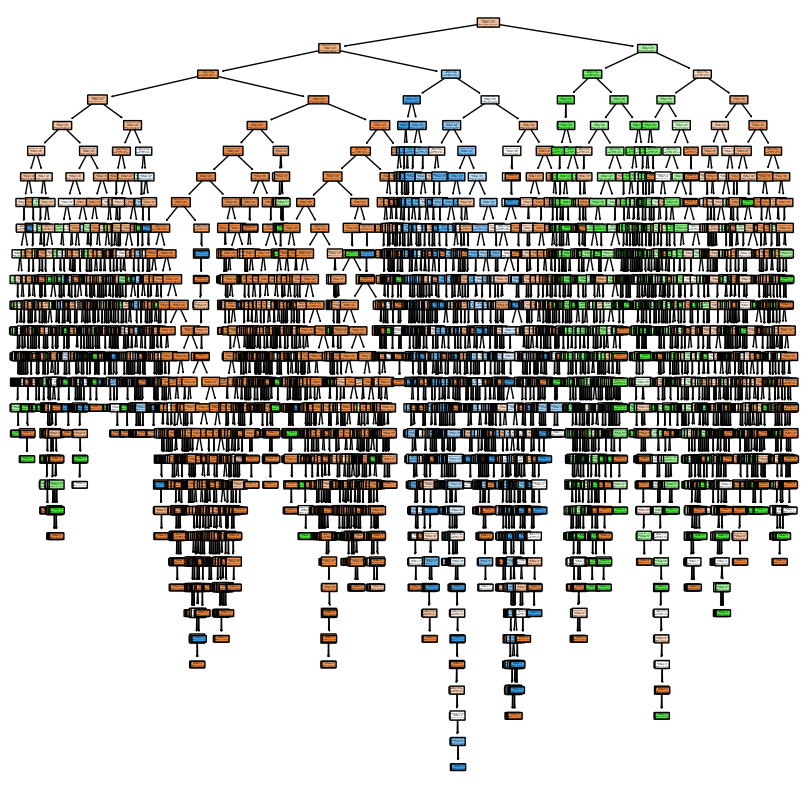

In [76]:
import matplotlib.pyplot as plt

def display_tree(tree, feature_names, class_names, figsize=(10,10)):
    plt.figure(figsize = figsize) # width, height in inches
    plot_tree(tree, 
          feature_names=feature_names,
          class_names=class_names,
          filled=True, rounded=True)
    plt.show()

display_tree(sk_dt, list(int_col_names_dum),list(y))

## 3. Predictions
After the model built we can use it to predict new examples. In this case, we will test with the same data used to train the model, the training data composed with 14 examples in order to verify if results are coherent

In [ ]:
preds = sk_dt.predict(df_laps_Xdum)

for i in range(df_laps_Xdum.shape[0]):
    print(f"real Class: {y[i]}; Predicted Class: {preds[i]} ")
    
print("\nTotal Number of errors or wrong predictions: ", sum(preds!=y))

Yeah, the model is perfect in terms of predicting the training data classes. Of ocurse we want that it will predict future data not used for learning. But we will deal with that later.

In [207]:
a = np.array([[29, 23, 24, 76, 92, 11]])
sk_dt.predict(a)

array(['accelerate+rotLeft'], dtype=object)

As it is easier to work with the `dataframe`, we should convert the `ndarray` obtained from the inout data (matrice `X`) into a `dataframe`:

In [92]:
pd.DataFrame(X, columns = d_iris.feature_names)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In clear contrast with the tennis dataset all variables are continuous and we do not need to make any other processing in the data, enabling us to go directily to the process of building a model that fits the data.

Lets build and display the Iris tree. We use two methods to show the tree length and number of leaves:`get_depth()` and  `get_n_leaves()` 

Tree depth: 5
Number of leaves: 9


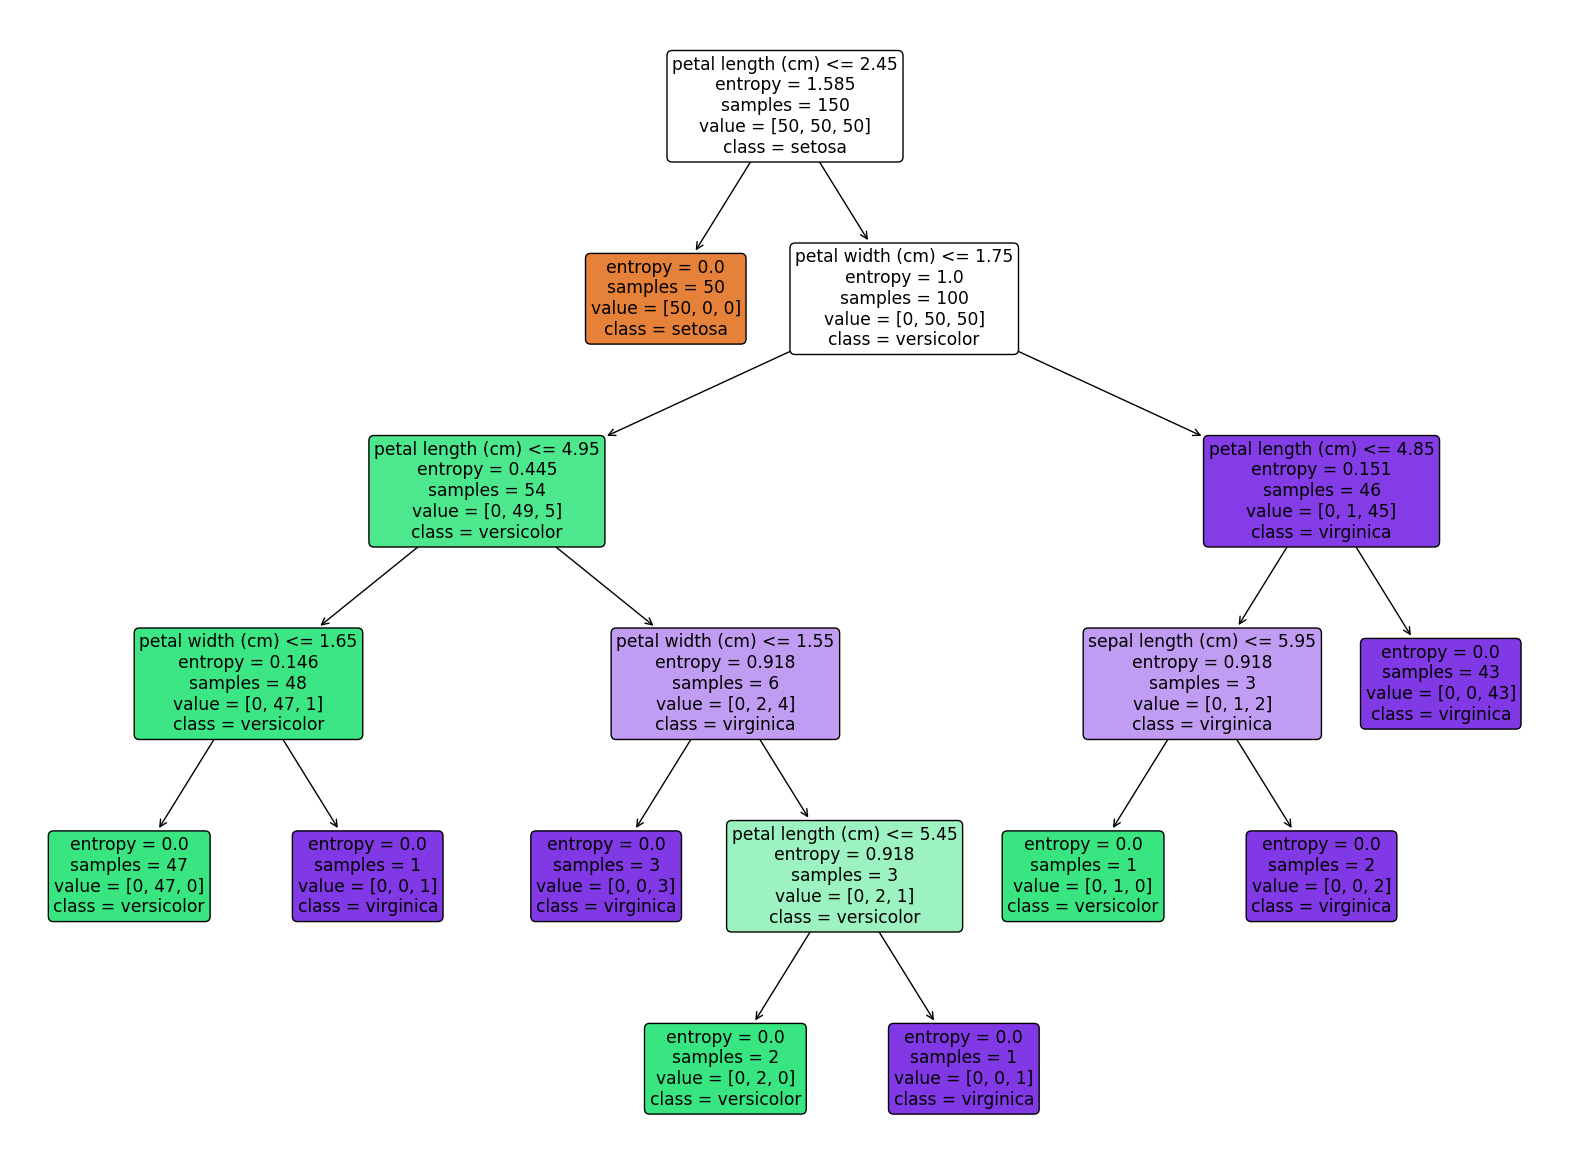

In [104]:
#from sklearn.datasets import load_iris
#from sklearn.tree import DecisionTreeClassifier, plot_tree

# leitura dos dados
iris_data = load_iris()
X = iris_data['data']
y = iris_data['target_names'][iris_data.target]

# construção do modelo
dt_iris = DecisionTreeClassifier(criterion='entropy')
dt_iris.fit(X,y)
print('Tree depth:', dt_iris.get_depth())
print('Number of leaves:', dt_iris.get_n_leaves())

# Visualizr a árvore de decisão obtida
plt.figure(figsize=[20,15]) # width, height in inches
plot_tree(dt_iris, 
          feature_names = list(iris_data['feature_names']),
          class_names = list(iris_data['target_names']),
          filled=True, rounded=True)
plt.show()

We can predict the class of a new example using the `predict` method:

In [107]:
a=np.array([[1.5,2.4,1.6,5]])

In [109]:
dt_iris.predict(a)

array(['setosa'], dtype='<U10')

We can use get_params()` in order to get all the parameters

In [112]:
dt_iris.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': None,
 'splitter': 'best'}

## 6. Evaluate Machine Leaning Models

In order to evaluate a classifier quality of a classifier we cannot use the data used to build it, and there are several methods for dealing with the classifiers validation, namely:

* Cross-validation method *holdout* (a round of cross validation) in which the data set is divided into train and test data. The model is fitted with the train data and verified with test data.
* K-fold cross validation (K-fold CV). Data are divide in K separated sets, and for each set, a model is fitted to the k-1 remaining sets and validated in the set. In this way, the original data set is used for training and testing, and we need to fit k models.
* leave-one-out is essentially a limit case of K-fold CV, where k is equal to the dataset length $N$ and we fit and validate $N$ clasifiers.

In every case, chosen the best classifier model and its parameters, the full set is used to generate the final classifier. 

### 6.1. Validate a model using a train and test set

In order to validate a model we use new data (not used durig model training) for which we have the right supervised classificaton. This is done dividing the dataset into 2 parts.  (In this case the 150 examplos of the iris dataset). One part of the data is named **train set**, is used to train our model, and the rest of the dataset forms the **test set** and they will be used to verify the model quality and performance in temros of generallzation, predicting the right class of new and unseen examples.

Scikit-learn has a function <a href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html">`train_test_split`</a> that shuffles the dataset and divides it into 2 parts. This function, by default, extracts 75% of the dataset lines into the train set, and generates the trainset. The remaining 25% form the test set. These percentages can be adjusted but a 75%-25% split is considered a good practice (*rule of thumb*).

This function has some useful parameters:
* the first 2 arguments are the data matrice and the class vector;
* `test_size` - by default it uses the `train_size` complement or or 0.25 if `train_size` is not defined;
* `train_size` - by default it uses the `test_size` complement, and corresponds to the percentage of points to consider in the training set;
* `random_state` - controls the randomness in the examples choice: if we set it to some integer it is possible to replicate te shuffling process and clone an experience.

It returns 4 outputs:
* the train set (`X_train`);
* the test set (`X_test`), they are both numpy arrays with the features data:
* the train classes (`y_train`);
* the test classes (`y_test`), both are numpy arrays.

### 6.2  Train and test data split in the Iris dataset
Lets divide the Iris dataset using the default percentages:

In [211]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_laps_Xdum_val, y, random_state=2)

We have 112 instances or points for training (just the feature values

In [214]:
X_train.shape

(8271, 6)

and the corresponding classes

In [217]:
y_train.shape

(8271,)

and 38 for validation

In [220]:
X_test.shape

(2757, 6)

Next we build a decision tree uisng only the train set.

In [223]:
dtc = DecisionTreeClassifier(criterion='entropy')
dtc.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy')

We are able to make prediction suing the test set and compare them wit the True claases (`y_test`), obtaining the *accuracy* of our model, the fraction of the test flowers that were correctly predicted. 

In order to obtain the accuracy we use the `score` method from the class `DecisionTreeClassifier`.

In [226]:
dtc.score(X_train, y_train)

0.9817434409382179

In [228]:
dtc.score(X_test, y_test)

0.8171926006528836

Thus in this model the test accuracy is aproximately of 0.947, which means that 94.7% test set flowers were correctly classified. Another way to interpret this number is that we predict that in the future our model will classify 94.7% of the flowers correctly.

Note that in the case of the accuracy on the train set we have 100&. Generally the accuracy in the train set is higher than the test set one - the train set has a larger size than the test set.

### 6.3. Overfitting and Underfitting

Overfitted models are the ones that are too much fitted to the training data inhibiting them to generalize well to new yet unseen data - a high ccuracy in the training data and a low one in the test data. This is why the parameters enter in action. We usually want to look for the best parameters to create our models. Using the same train data we vary parameters and For each set of parameters we build a model and validate them in the test set..

In this case we are going to vary the `min_samples_split` decision tree parameter (between 2 and 10). The parameter sets the number of minimun points necessary to split a node. If the value is 2 it means that we can split a node even if there are 2 points - trees are not pruned and may be divided until a node has 1 or 0 items or points. 

Lets create those 9 nodels and mesure the resulting accuracy in the train and test sets. We build a graphic to display the accuracies.

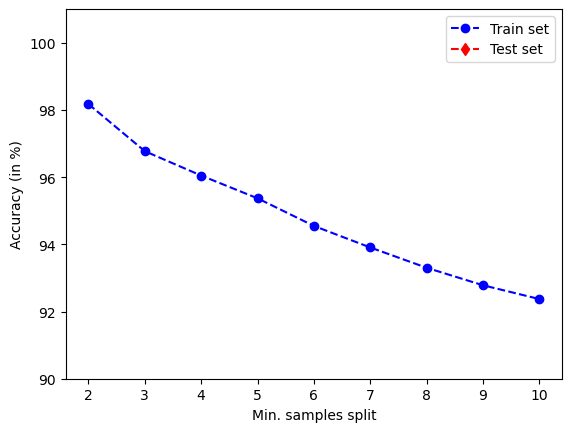

In [232]:
import matplotlib.pyplot as plt

train = []
test = []
for i in range(2,11):
    ad = DecisionTreeClassifier(criterion='entropy', min_samples_split=i)
    ad = ad.fit(X_train,y_train)
    train.append(ad.score(X_train,y_train)*100)
    test.append(ad.score(X_test,y_test)*100)

# fazer um gráfico com a accuracy
x = np.arange(2,11,1) # intervalo do eixo dos xx's
plt.plot(x, train, 'bo--', label='Train set')
plt.plot(x, test, 'rd--', label='Test set')
plt.ylim(90,101) # limite dos eixo dos yy's
plt.xlabel('Min. samples split') # legenda do eixo dos xx's
plt.ylabel('Accuracy (in %)') # legenda do eixo dos yy's
plt.legend() # legenda
plt.show()

In the training set the accuracy is 100% when the parameter has a value of 2 and 3 and this means that the learned trr is too much fitted to the trainings set and as the test set is not the highest onem it will be able to improve the generalization to new data.

Note that if we increase too much the parameter value (p.ex., `min_samples_split=42`), the model will not be able to learn. The accuracy in the train decreases and it also decrease in the test set.y **underfitting** to data.

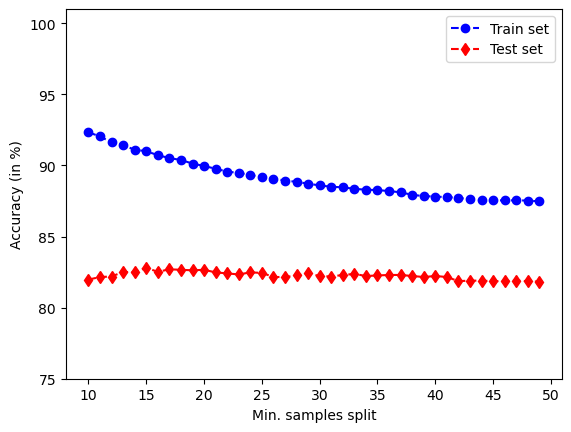

In [234]:
train = []
test = []
for i in range(10,50):
    ad = DecisionTreeClassifier(criterion='entropy', min_samples_split=i)
    ad = ad.fit(X_train,y_train)
    train.append(ad.score(X_train,y_train)*100)
    test.append(ad.score(X_test,y_test)*100)

# fazer um gráfico com a accuracy
x = np.arange(10,50,1) # intervalo do eixo dos xx's
plt.plot(x, train, 'bo--', label='Train set')
plt.plot(x, test, 'rd--', label='Test set')
plt.ylim(75,101) # limite dos eixo dos yy's
plt.xlabel('Min. samples split') # legenda do eixo dos xx's
plt.ylabel('Accuracy (in %)') # legenda do eixo dos yy's
plt.legend() # legenda
plt.show()

In resume, **overfitting** occurs if we fit the model to the particularities of the train set, resulting in a too much complex model unable to generalize to new data. **Underfitting** occurs if the model is too simple being unable to capture all the aspects and variabilities of the data, with a poor performance in both sets.

### Other parameters to control overfititng
* `max_depth` - by dfault it is `None`, but we can choose an integer for this parameter. It won't go on splitting if the tree max depth is exceeded.
* `min_samples_split` - tem o valor de 2 por defeito, mas pode-se escolher um valor inteiro para este parâmetro. Este parâmetro não permite expandir a árvore para subconjuntos da dados menores que um dado valor, i.e., proibe o algoritmo de dividir nós com menos do que o  número de exemplos fornecido.
* `min_samples_leaf` - 1 by default. This parameter defines the minimum number if examples in the leafs. There won'be any slit that results in a leaf with less than the value of the parameter.

These parameters by be combined in order to control overfitting.

Lets vary max_depth from 1 ro 5 and plot the accuracy performance in both sets: train and test

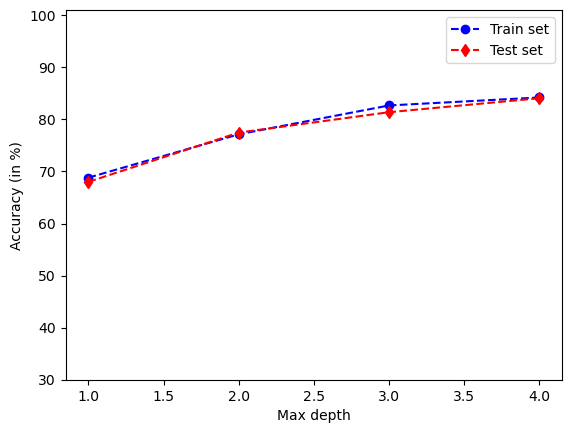

In [240]:
train = []
test = []
for i in range(1,5):
    ad = DecisionTreeClassifier(criterion='entropy', max_depth=i)
    ad = ad.fit(X_train,y_train)
    train.append(ad.score(X_train,y_train)*100)
    test.append(ad.score(X_test,y_test)*100)

# fazer um gráfico com a accuracy
x = np.arange(1,5,1) # intervalo do eixo dos xx's
plt.plot(x, train, 'bo--', label='Train set')
plt.plot(x, test, 'rd--', label='Test set')
plt.ylim(30,101) # limite dos eixo dos yy's
plt.xlabel('Max depth') # legenda do eixo dos xx's
plt.ylabel('Accuracy (in %)') # legenda do eixo dos yy's
plt.legend() # legenda
plt.show()

### PostPruning
The parameters we have seen deal with pre-pruning the tree, during the tree generation process. There are techniques for post-pruning the that deal with overfitting.
See for example:<a href="https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html">`cost complexity pruning`</a> 

### Repeated spliting intor train and test: shuffling
Our train and test split is random. And qwe may try other divisins. What happens if we make a different random split? (through a change in the values of `random_state`). 

In [244]:
X_train, X_test, y_train, y_test = train_test_split(df_laps_Xdum_val, y, random_state=8)

dtc = DecisionTreeClassifier(criterion='entropy')
dtc.fit(X_train, y_train)
print('Decision Tree')
print('Accuracy train:', dtc.score(X_train,y_train))
print('Accuracy test:', dtc.score(X_test,y_test))

Decision Tree
Accuracy train: 0.9815016322089227
Accuracy test: 0.8211824446862531


In [249]:
from sklearn.model_selection import cross_val_score
dtc = DecisionTreeClassifier(criterion='entropy')
scores = cross_val_score(dtc,
                         X = df_laps_Xdum_val,
                         y = y,
                         cv = 10
                         
                        )

print('CV accuracy:', *scores, sep='\n\t')
print('Average CV accuracy: %.3f +/- %.3f' %(np.mean(scores), np.std(scores)))

CV accuracy:
	0.7887579329102448
	0.7561196736174071
	0.7606527651858568
	0.772438803263826
	0.7642792384406165
	0.6627379873073436
	0.7334542157751587
	0.6863100634632819
	0.7078039927404719
	0.7713248638838476
Average CV accuracy: 0.740 +/- 0.040
